### Transforms

`transforms` is used to preprocess images before giving them to a model.

Main idea:

```text
PIL image -> transform -> tensor -> model
```

In this notebook, we use one ant image to see what `ToTensor`, `Normalize`, and `Compose` do.


#### 1. Structure and Utilization

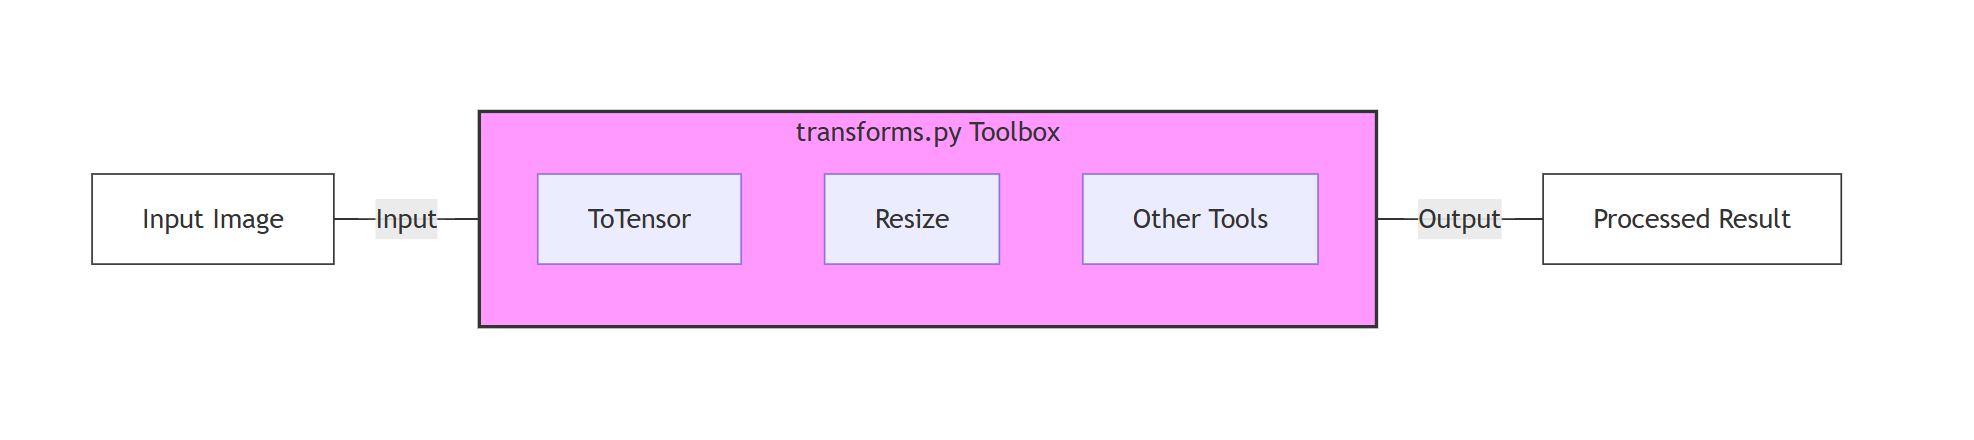

A transform is usually passed into a `Dataset`. When the dataset loads one image, it applies the transform and returns the processed result.


#### 2. Import Packages and Open One Image

We use the same hymenoptera dataset from the previous notes.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms

# Use a relative path from this notebook folder.
img_path = Path("datasets/hymenoptera_data/train/ants/0013035.jpg")

# Open the image with PIL and convert it to RGB so it has 3 color channels.
img = Image.open(img_path).convert("RGB")

# Create one TensorBoard writer for the image examples in this notebook.
writer = SummaryWriter("logs/transforms")

print(type(img))
print(img.size)  # PIL image size is (width, height).
img


#### 3. `ToTensor()`

`ToTensor()` converts a PIL image into a PyTorch tensor.

It also changes:

- pixel values from `[0, 255]` to `[0.0, 1.0]`;
- image shape from `H x W x C` to `C x H x W`.


In [ ]:
# Create a transform object that converts a PIL image to a tensor.
trans_totensor = transforms.ToTensor()

# Apply the transform to the PIL image.
img_tensor = trans_totensor(img)

# Log the tensor image so it can be viewed in TensorBoard.
writer.add_image("ToTensor", img_tensor, global_step=0)

print(type(img_tensor))
print(img_tensor.shape)  # Tensor image shape is (channels, height, width).
print(img_tensor.min().item(), img_tensor.max().item())  # ToTensor changes values to [0, 1].


#### 4. `Normalize()`

`Normalize(mean, std)` uses this formula:

```text
output = (input - mean) / std
```

For an RGB image, `mean` and `std` each need three values.


In [ ]:
# Look at one pixel value before normalization.
print(img_tensor[0][0][0])

# Normalize each RGB channel with mean=0.5 and std=0.5.
# Since img_tensor values are in [0, 1], this changes them roughly to [-1, 1].
trans_norm = transforms.Normalize(
    mean=[0.5, 0.5, 0.5],
    std=[0.5, 0.5, 0.5],
)

img_norm = trans_norm(img_tensor)

print(img_norm.shape)
print(img_norm.min().item(), img_norm.max().item())


#### 5. `Resize()`

`Resize()` changes the image size. It is usually applied before `ToTensor()` because PIL images are easy to resize.


In [ ]:
print(img.size)  # Original PIL image size.

# Resize the PIL image to 512 x 512.
trans_resize = transforms.Resize((512, 512))
img_resize = trans_resize(img)

print(img_resize.size)  # Resized PIL image size.

# Convert the resized PIL image to a tensor.
img_resize_tensor = trans_totensor(img_resize)
print(img_resize_tensor.shape)


#### 6. `Compose()`

`Compose()` puts multiple transforms together. This is the form most often used in a dataset.

The order matters: resize first, convert to tensor second, normalize last.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Make every image the same size.
    transforms.ToTensor(),        # Convert PIL image to tensor and scale values to [0, 1].
    transforms.Normalize(         # Normalize the tensor values channel by channel.
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

result = transform(img)
print(result.shape)


#### 7. Display a Tensor Image

Matplotlib wants image shape `H x W x C`, so we use `permute(1, 2, 0)` before displaying.

If the image was normalized, convert it back first. This display step fits after `Compose()` because `result` is the final transformed tensor.


In [ ]:
# Undo Normalize(mean=0.5, std=0.5) so the image can be displayed correctly.
img_show = result * 0.5 + 0.5
img_show = img_show.clamp(0, 1)

# Change tensor shape from C x H x W to H x W x C for Matplotlib.
plt.imshow(img_show.permute(1, 2, 0))
plt.axis("off");


#### 8. Write Image to TensorBoard

This belongs after the display step because we already converted the normalized tensor back to a viewable image.

The image will appear in TensorBoard's **Images** tab.


In [ ]:
# Save the display-ready image to TensorBoard.
writer.add_image("ants/transformed", img_show, global_step=0)

# Close the writer after all logging is finished.
writer.close()


#### 9. Terminal Commands

Run this in the terminal from this notebook folder after executing the TensorBoard logging cells:

```bash
tensorboard --logdir=logs
```

Then open the URL shown in the terminal, usually:

```text
http://localhost:6006/
```

If the port is already used:

```bash
tensorboard --logdir=logs --port=6007
```


#### Checklist

- Use `Resize()` when images need the same size.
- Use `ToTensor()` before giving an image to a PyTorch model.
- Use three `mean` and `std` values for RGB images.
- Use `Compose()` when several transforms need to run in order.
- Put transforms in a sensible order: `Resize -> ToTensor -> Normalize`.
- Use `permute(1, 2, 0)` when displaying a tensor image with Matplotlib.
